In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

In [2]:
# Warning suppression
import warnings
warnings.filterwarnings(
    "ignore",
    message="The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.",
    category=UserWarning,
    module="cartopy.mpl.geoaxes"
)

In [3]:
def plot_exps(clusters,titles,plev,clevs,latreg=None,lonreg=None):

    varnames=['u','v']
    nrows=2
    ncols=2
    #plev=200
   # plev=850
   # clevs=np.arange(-10,11,1)
    #clevs=np.arange(-2,2.5,0.5)
    ccolor='RdGy_r'
    
    for v in varnames:
    
        f, axs = pplt.subplots(nrows=nrows, ncols=ncols, span=False, proj='pcarree',
                               proj_kw={'central_longitude': 210},
                               figsize=(11.0, 8.5),
                               sharex=False, sharey=False)
        axs.format(abcloc='l', abc='(a)',
                   latlines=10,     # Draw latitude lines every 15°
                   lonlines=30,     # Draw longitude lines every 30°
                   latlabels=True,  # Show latitude labels
                   lonlabels=True   # Show longitude labels
        )
        for ax, cluster, title in zip(axs, clusters, titles):

            cs = ax.contourf(cluster['lon'].values, cluster['lat'].values,
                             cluster[v].sel(lev=plev).values,
                             norm='div', levels=clevs, cmap=ccolor, extend='both',
                             labels=False, labels_kw={'fontsize': 'large'})
            ax.format(
                title=title,
                reso='lo', coast=True, borders=True,
                coastcolor='black', borderscolor='black',
                innerborders=True, 
                latlim=latreg, lonlim=lonreg,
                lonlabels='b', latlabels='l',
                latlines=20, lonlines=30,
                grid=True,# to show gridlines
                fontsize=14,  # Larger title and labels
                titleweight='bold',  # Make the title bold
                labelweight='bold',  # Make axis labels bold
                linewidth=2,  # Make map frame bold
                )



        # Add colorbar at the bottom
        f.colorbar(cs, loc='b', length=0.6, label="ms-1")


In [4]:
def plot_convergence(clusters,titles,plev,clevs,latreg=None,lonreg=None):

    nrows=2
    ncols=2
    ccolor='RdGy_r'
    
    f, axs = pplt.subplots(nrows=nrows, ncols=ncols, span=False, proj='pcarree',
                           proj_kw={'central_longitude': 210},
                           figsize=(11.0, 8.5),
                           sharex=False, sharey=False)
    axs.format(abcloc='l', abc='(a)',
               latlines=10,     # Draw latitude lines every 15°
               lonlines=30,     # Draw longitude lines every 30°
               latlabels=True,  # Show latitude labels
               lonlabels=True   # Show longitude labels
    )
    for ax, cluster, title in zip(axs, clusters, titles):
        print(cluster)
        cs = ax.contourf(cluster['lon'], cluster['lat'],
                         cluster,
                         norm='div', levels=clevs, cmap=ccolor, extend='both',
                         labels=False, labels_kw={'fontsize': 'large'})
        ax.format(
            title=title,
            reso='lo', coast=True, borders=True,
            coastcolor='black', borderscolor='black',
            innerborders=True, 
            latlim=latreg, lonlim=lonreg,
            lonlabels='b', latlabels='l',
            latlines=20, lonlines=30,
            grid=True,# to show gridlines
            fontsize=14,  # Larger title and labels
            titleweight='bold',  # Make the title bold
            labelweight='bold',  # Make axis labels bold
            linewidth=2,  # Make map frame bold
            )



    # Add colorbar at the bottom
    f.colorbar(cs, loc='b', length=0.6, label="ms-1")


In [5]:
def plot_exps_winds(clusters,titles,plev,clevs,latreg=None,lonreg=None):

    varnames=['u','v']
    nrows=2
    ncols=2
    ccolor='RdGy_r'
    
    for v in varnames:
    
        f, axs = pplt.subplots(nrows=nrows, ncols=ncols, span=False, proj='pcarree',
                               proj_kw={'central_longitude': 210},
                               figsize=(11.0, 8.5),
                               sharex=False, sharey=False)
        axs.format(abcloc='l', abc='(a)',
                   latlines=10,     # Draw latitude lines every 15°
                   lonlines=30,     # Draw longitude lines every 30°
                   latlabels=True,  # Show latitude labels
                   lonlabels=True   # Show longitude labels
        )
        for ax, cluster, title in zip(axs, clusters, titles):

            cs = ax.quiver(cluster['lon'].values, cluster['lat'].values,
                             cluster['u'].sel(lev=plev).values,
                             cluster['v'].sel(lev=plev).values)
            ax.format(
                title=title,
                reso='lo', coast=True, borders=True,
                coastcolor='black', borderscolor='black',
                innerborders=True, 
                latlim=latreg, lonlim=lonreg,
                lonlabels='b', latlabels='l',
                latlines=20, lonlines=30,
                grid=True,# to show gridlines
                fontsize=14,  # Larger title and labels
                titleweight='bold',  # Make the title bold
                labelweight='bold',  # Make axis labels bold
                linewidth=2,  # Make map frame bold
                )



        # Add colorbar at the bottom
        f.colorbar(cs, loc='b', length=0.6, label="ms-1")


In [6]:
#expnames=['HeatingJJA','Cluster1_TP','Cluster2_TP','Cluster3_TP','Cluster4_TP']
expnames=['HeatingJJA','Cluster1_EA','Cluster2_EA','Cluster3_EA','Cluster4_EA',
          'Cluster1_TP','Cluster2_TP','Cluster3_TP','Cluster4_TP']

basepath='/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/'
DataSetname = ['uvel','vvel']
Dataname = ['u','v'] 

In [7]:
ds_exps_list=[]
for e in expnames:
    datapath=basepath+'T63L26_'+e+'/'
    ds_list=[]
    for dsn,dn in zip(DataSetname,Dataname):
        fnames=datapath+dsn+'_Pressure_days_*.nc'
        print(fnames)
        ds=xr.open_mfdataset(fnames,combine='by_coords')
        ds_list.append(ds)
    ds_all=xr.merge(ds_list)  
    ds_exps_list.append(ds_all)
ds_exps=xr.combine_nested(ds_exps_list,concat_dim='exp')
ds_exps['exp']=expnames

/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_HeatingJJA/uvel_Pressure_days_*.nc


/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_HeatingJJA/vvel_Pressure_days_*.nc
/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_Cluster1_EA/uvel_Pressure_days_*.nc
/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_Cluster1_EA/vvel_Pressure_days_*.nc
/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_Cluster2_EA/uvel_Pressure_days_*.nc
/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_Cluster2_EA/vvel_Pressure_days_*.nc
/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_Cluster3_EA/uvel_Pressure_days_*.nc
/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_Cluster3_EA/vvel_Pressure_days_*.nc
/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_Cluster4_EA/uvel_Pressure_days_*.nc
/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_Cluster4_EA/vvel_Pressure_days_*.nc
/data/esplab/kpegion/projects

In [8]:
ds_exps_means=ds_exps.mean(dim='time')

In [9]:
diff_cluster1=ds_exps_means.sel(exp='Cluster1_EA')-ds_exps_means.sel(exp='HeatingJJA')
diff_cluster2=ds_exps_means.sel(exp='Cluster2_EA')-ds_exps_means.sel(exp='HeatingJJA')
diff_cluster3=ds_exps_means.sel(exp='Cluster3_EA')-ds_exps_means.sel(exp='HeatingJJA')
diff_cluster4=ds_exps_means.sel(exp='Cluster4_EA')-ds_exps_means.sel(exp='HeatingJJA')

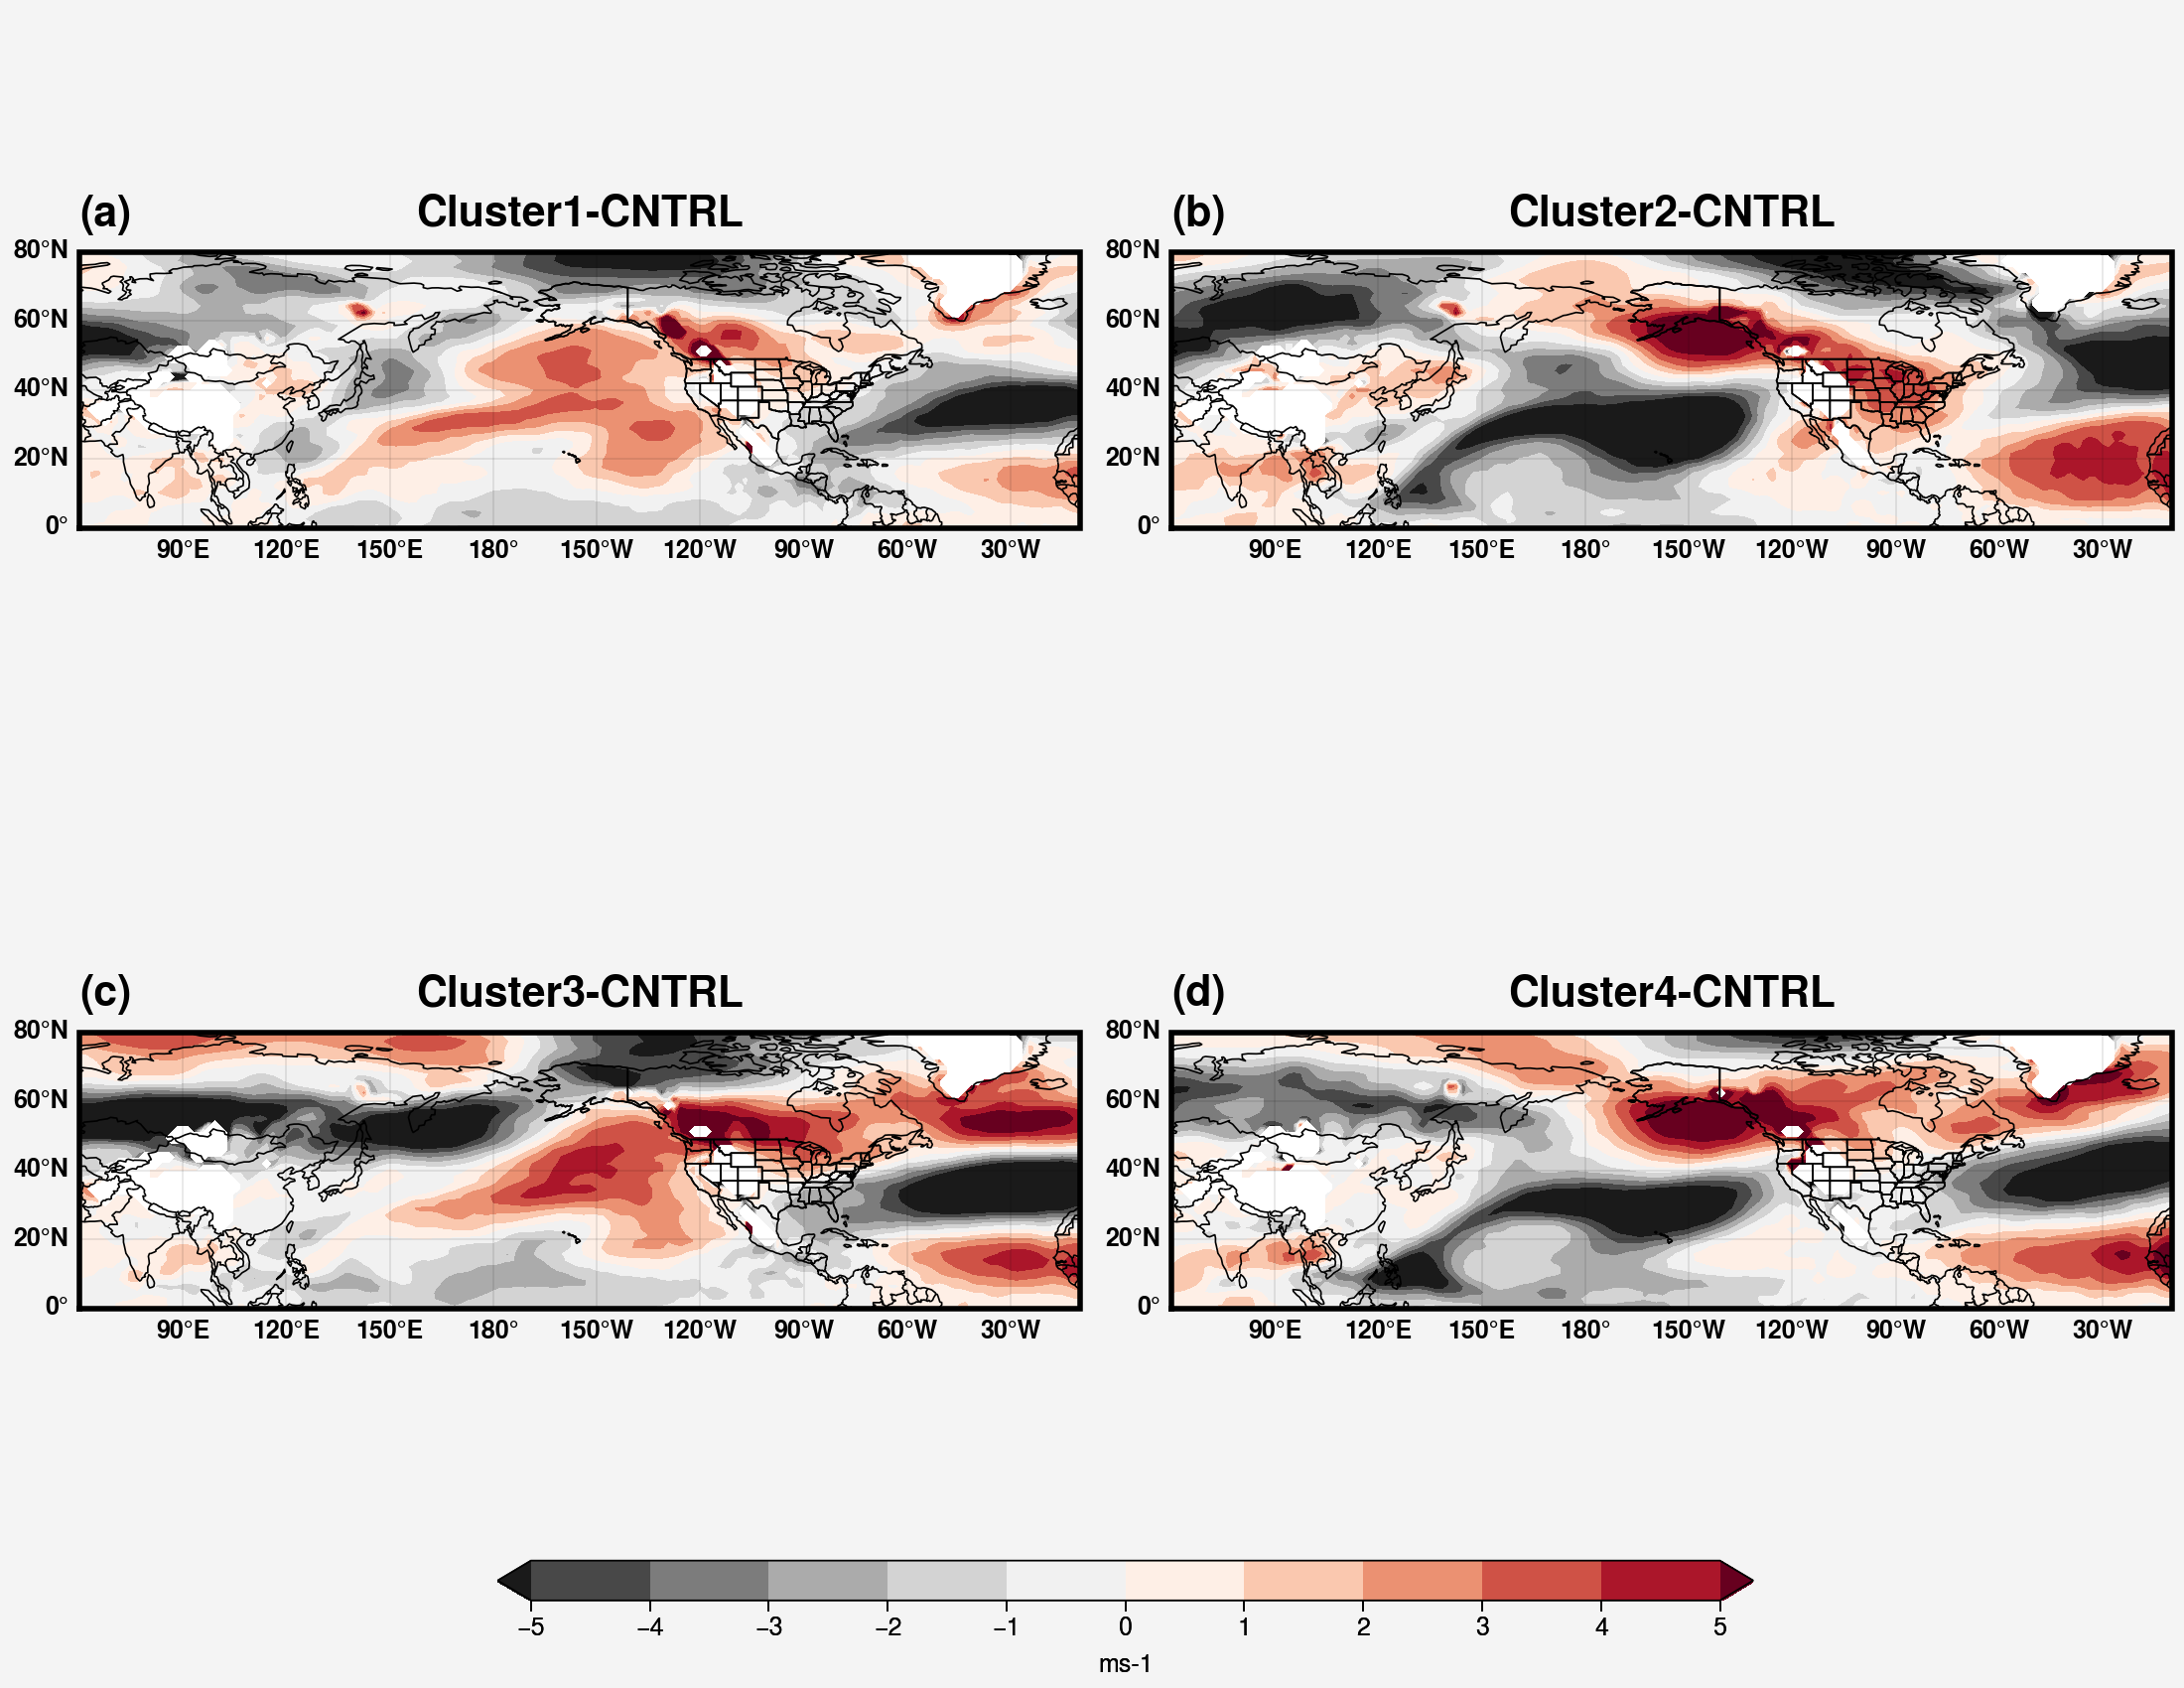

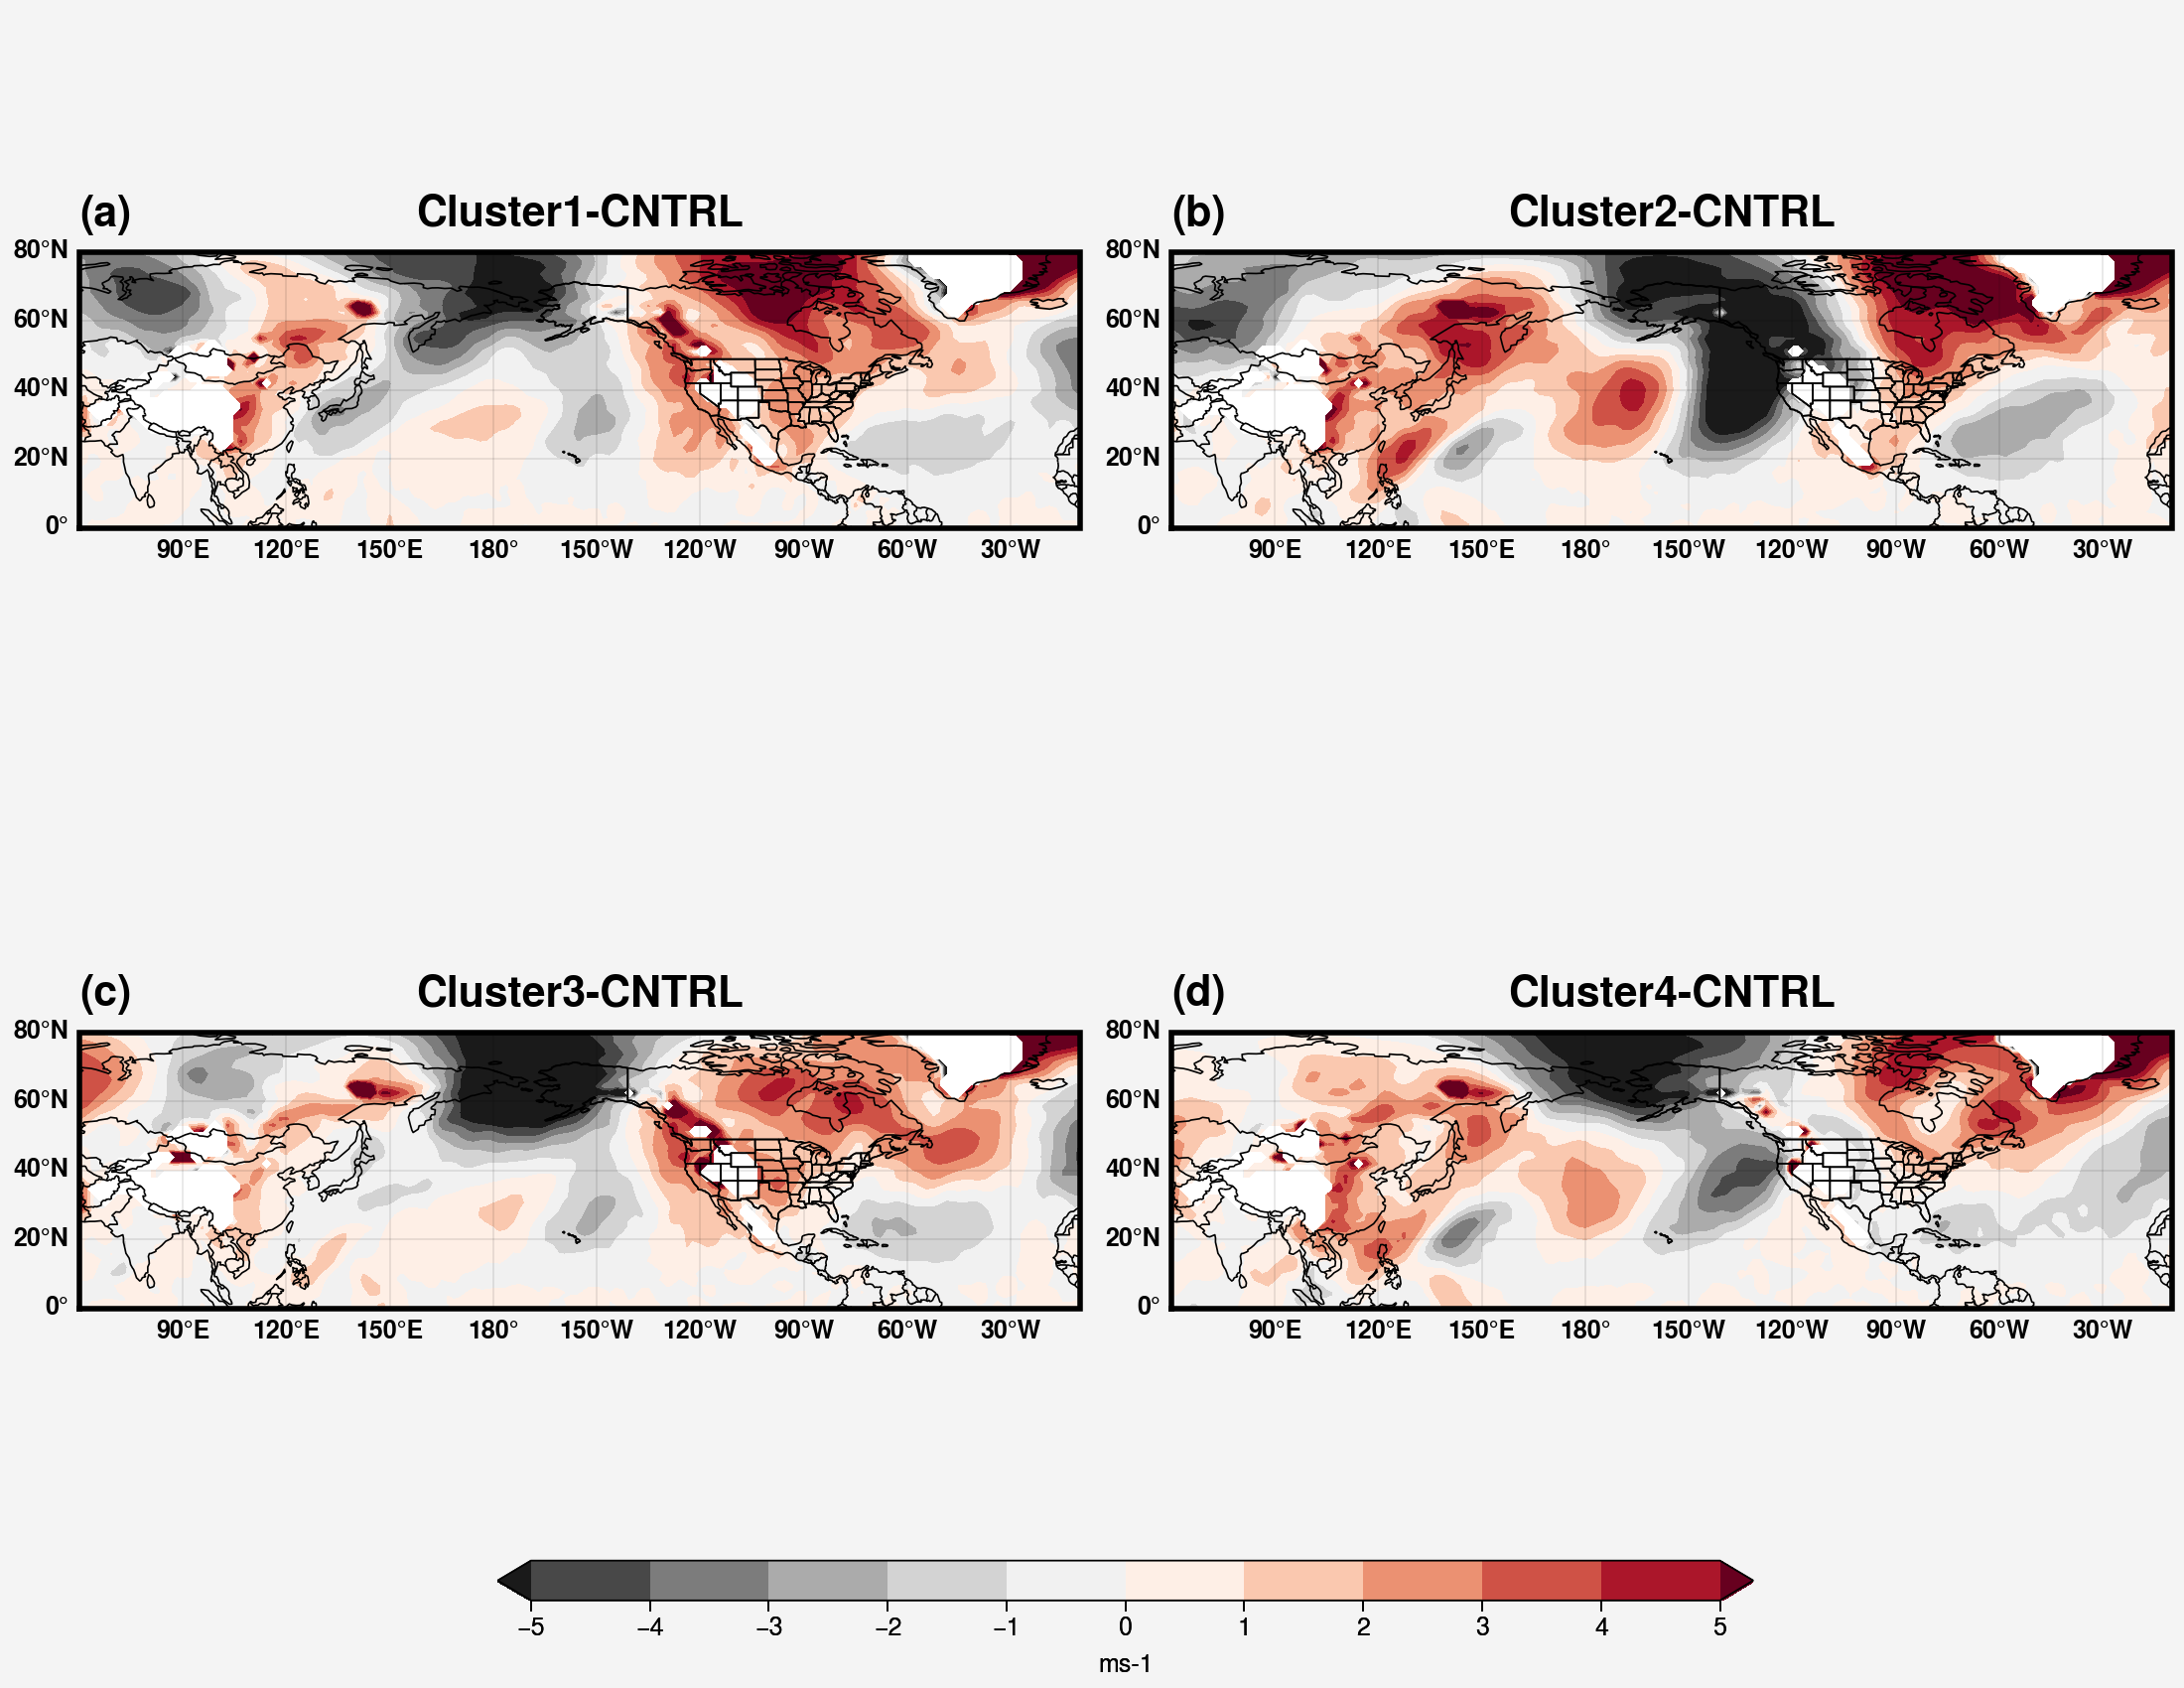

In [10]:
clusters = [diff_cluster1, diff_cluster2, diff_cluster3, diff_cluster4]
titles = ['Cluster1-CNTRL', 'Cluster2-CNTRL', 'Cluster3-CNTRL', 'Cluster4-CNTRL']
#plev=200
#clevs=np.arange(-10,11,1)
plev=850
clevs=np.arange(-5,6,1)
latreg=[0,80]
lonreg=[60,350]
plot_exps(clusters,titles,plev,clevs,latreg=latreg,lonreg=lonreg)

<xarray.DataArray 'convergence' (lat: 95, lon: 191)>
dask.array<mul, shape=(95, 191), dtype=float64, chunksize=(95, 191), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 86.72 84.86 83.0 81.13 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
    lev      float64 850.0
<xarray.DataArray 'convergence' (lat: 95, lon: 191)>
dask.array<mul, shape=(95, 191), dtype=float64, chunksize=(95, 191), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 86.72 84.86 83.0 81.13 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
    lev      float64 850.0
<xarray.DataArray 'convergence' (lat: 95, lon: 191)>
dask.array<mul, shape=(95, 191), dtype=float64, chunksize=(95, 191), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 86.72 84.86 83.0 81.13 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 3

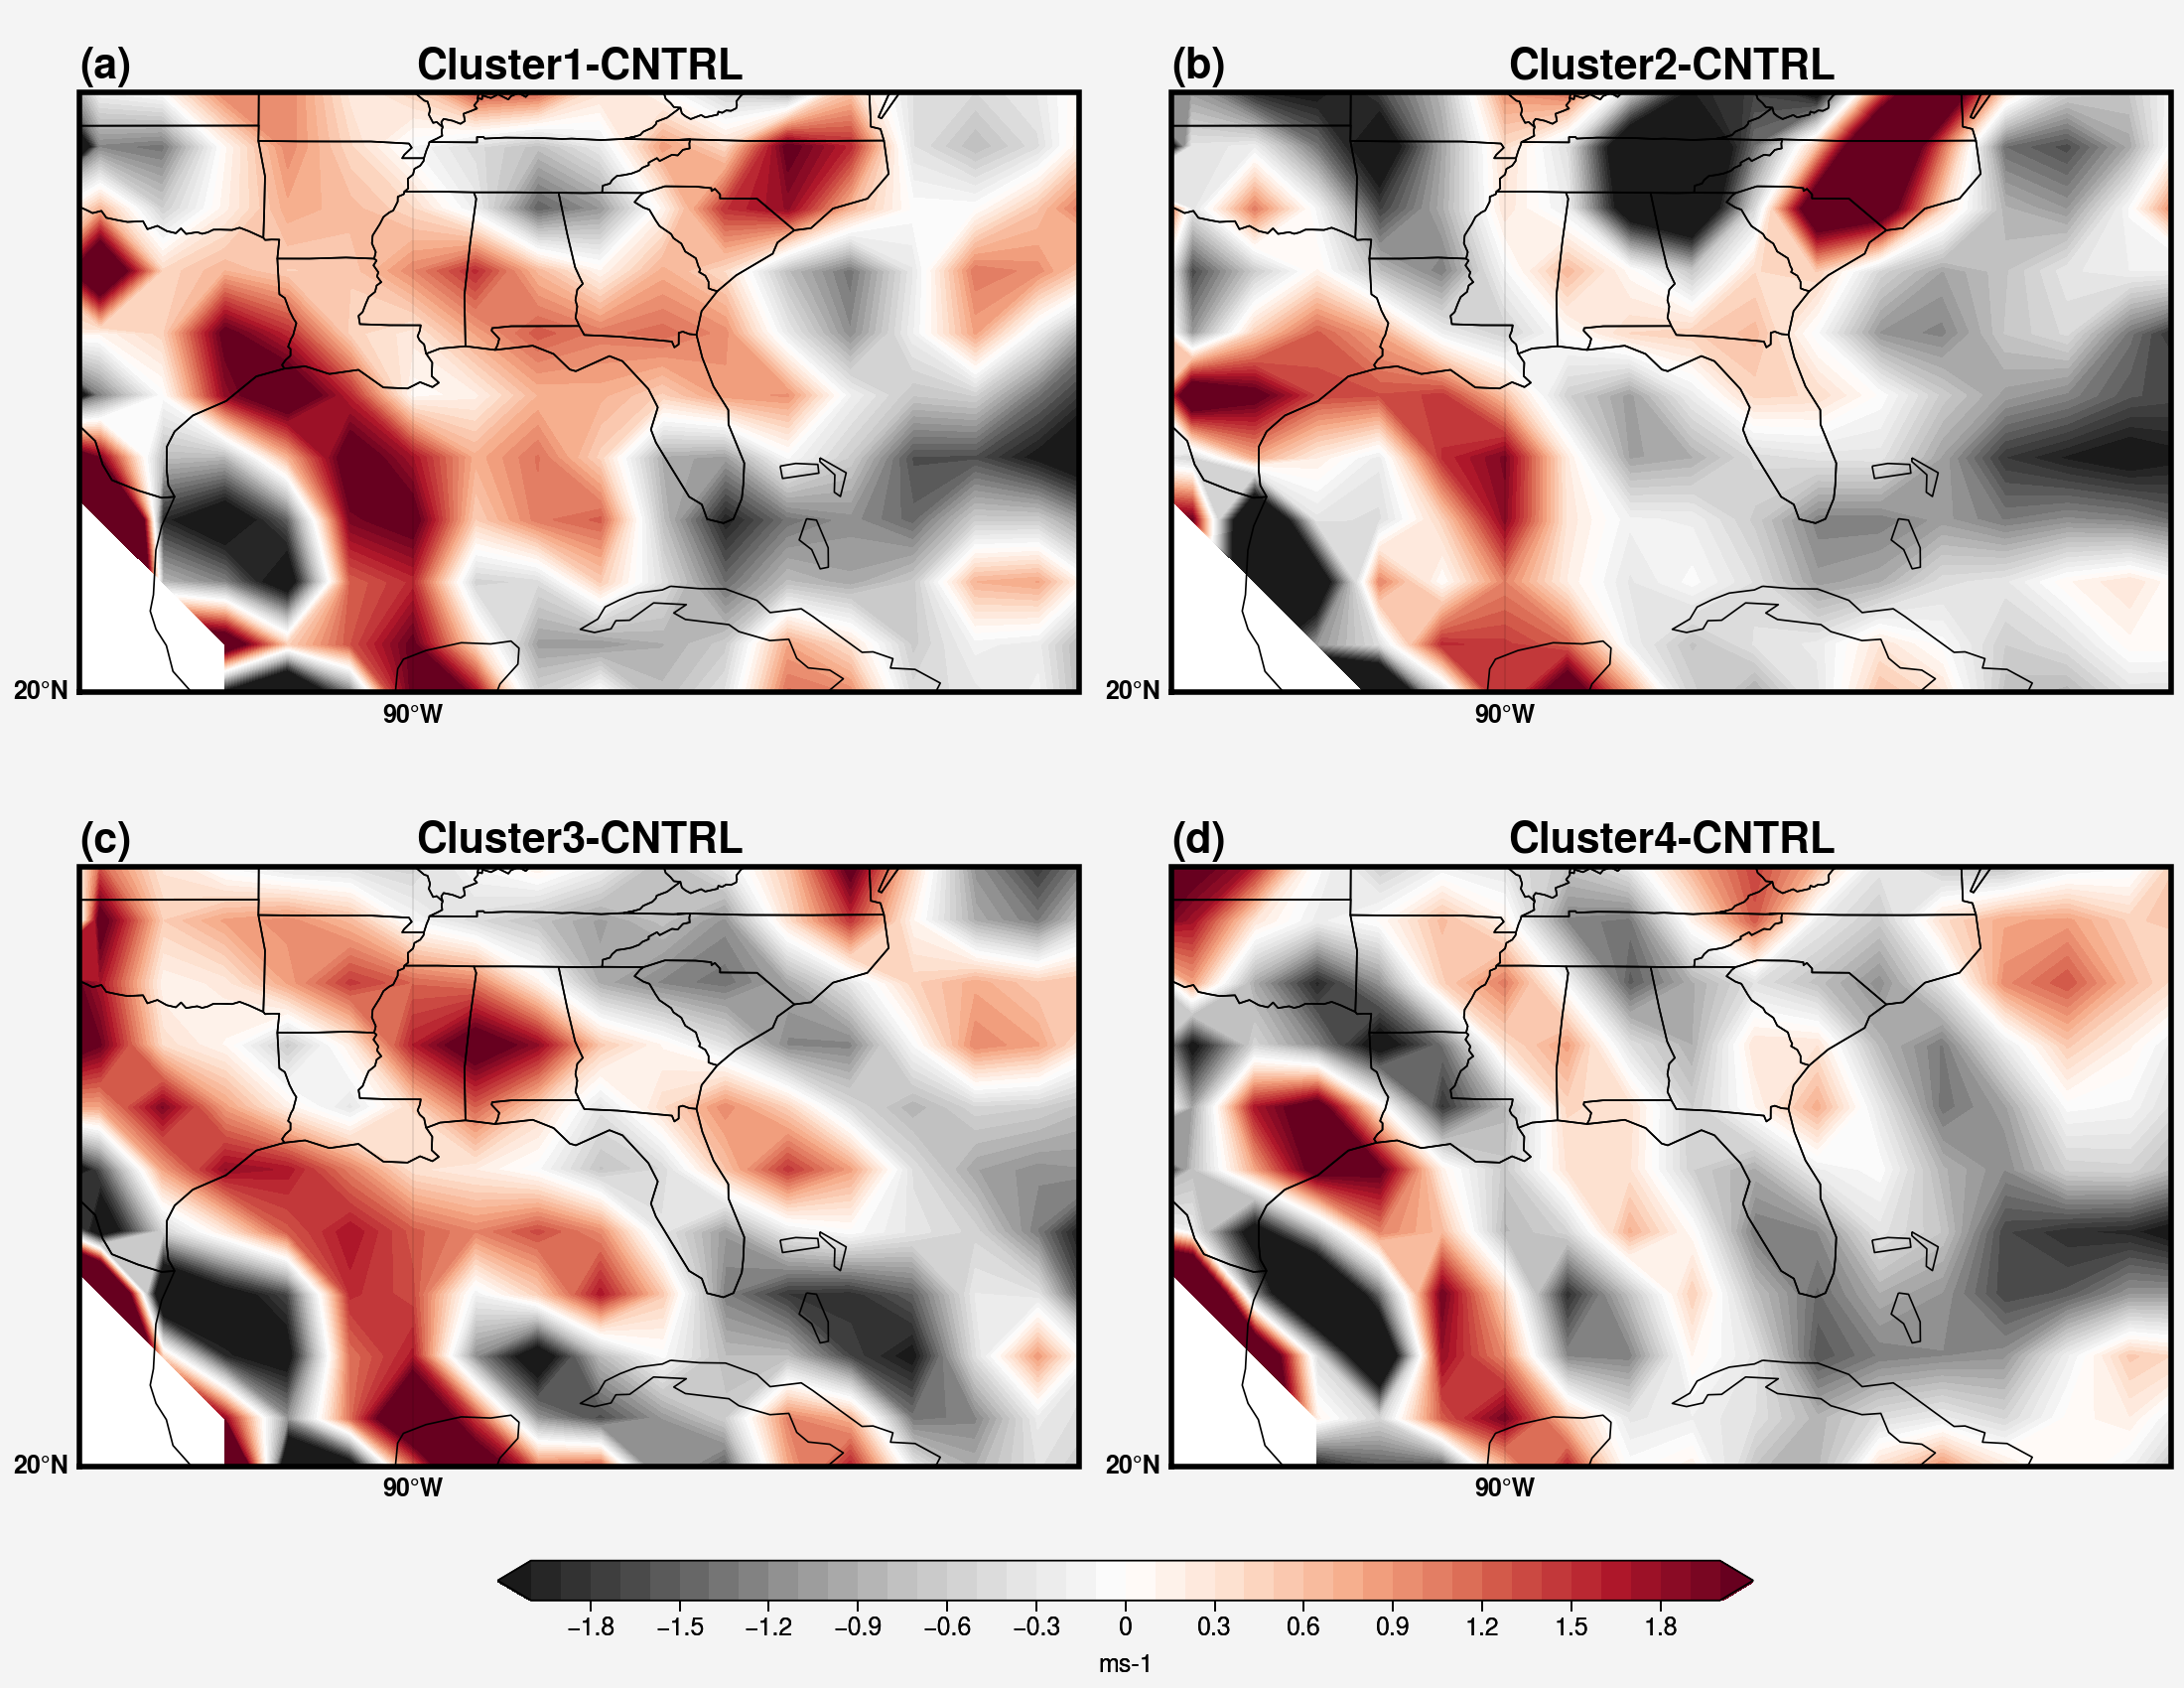

In [11]:
convergence_list = []

for ds in clusters:
    u = ds['u'].sel(lev=850)
    v = ds['v'].sel(lev=850)

    # Earth radius and lat in radians
    Re = 6.371e6
    lat_rad = np.deg2rad(u.lat)

    # dx, dy in meters
    dx = (2 * np.pi * Re * np.cos(lat_rad) / 360) * u.lon.diff('lon').mean()
    dy = (2 * np.pi * Re / 360) * u.lat.diff('lat').mean()

    du_dx = u.diff('lon') / dx
    dv_dy = v.diff('lat') / dy

    # Pad to match original shape
    du_dx = du_dx.pad(lon=(0, 1), mode='constant', constant_values=np.nan)
    dv_dy = dv_dy.pad(lat=(0, 1), mode='constant', constant_values=np.nan)

    convergence = -(du_dx + dv_dy)
    convergence.name = 'convergence'

    convergence_list.append(convergence * 1e6)  # Convert to 10^-5 s^-1
clevs=np.arange(-2,2.1,0.1) 
latreg=[20,38]
lonreg=[260,290]
plot_convergence(convergence_list, titles, plev, clevs, latreg=latreg, lonreg=lonreg)

In [12]:
diff_cluster1=ds_exps_means.sel(exp='Cluster1_TP')-ds_exps_means.sel(exp='HeatingJJA')
diff_cluster2=ds_exps_means.sel(exp='Cluster2_TP')-ds_exps_means.sel(exp='HeatingJJA')
diff_cluster3=ds_exps_means.sel(exp='Cluster3_TP')-ds_exps_means.sel(exp='HeatingJJA')
diff_cluster4=ds_exps_means.sel(exp='Cluster4_TP')-ds_exps_means.sel(exp='HeatingJJA')

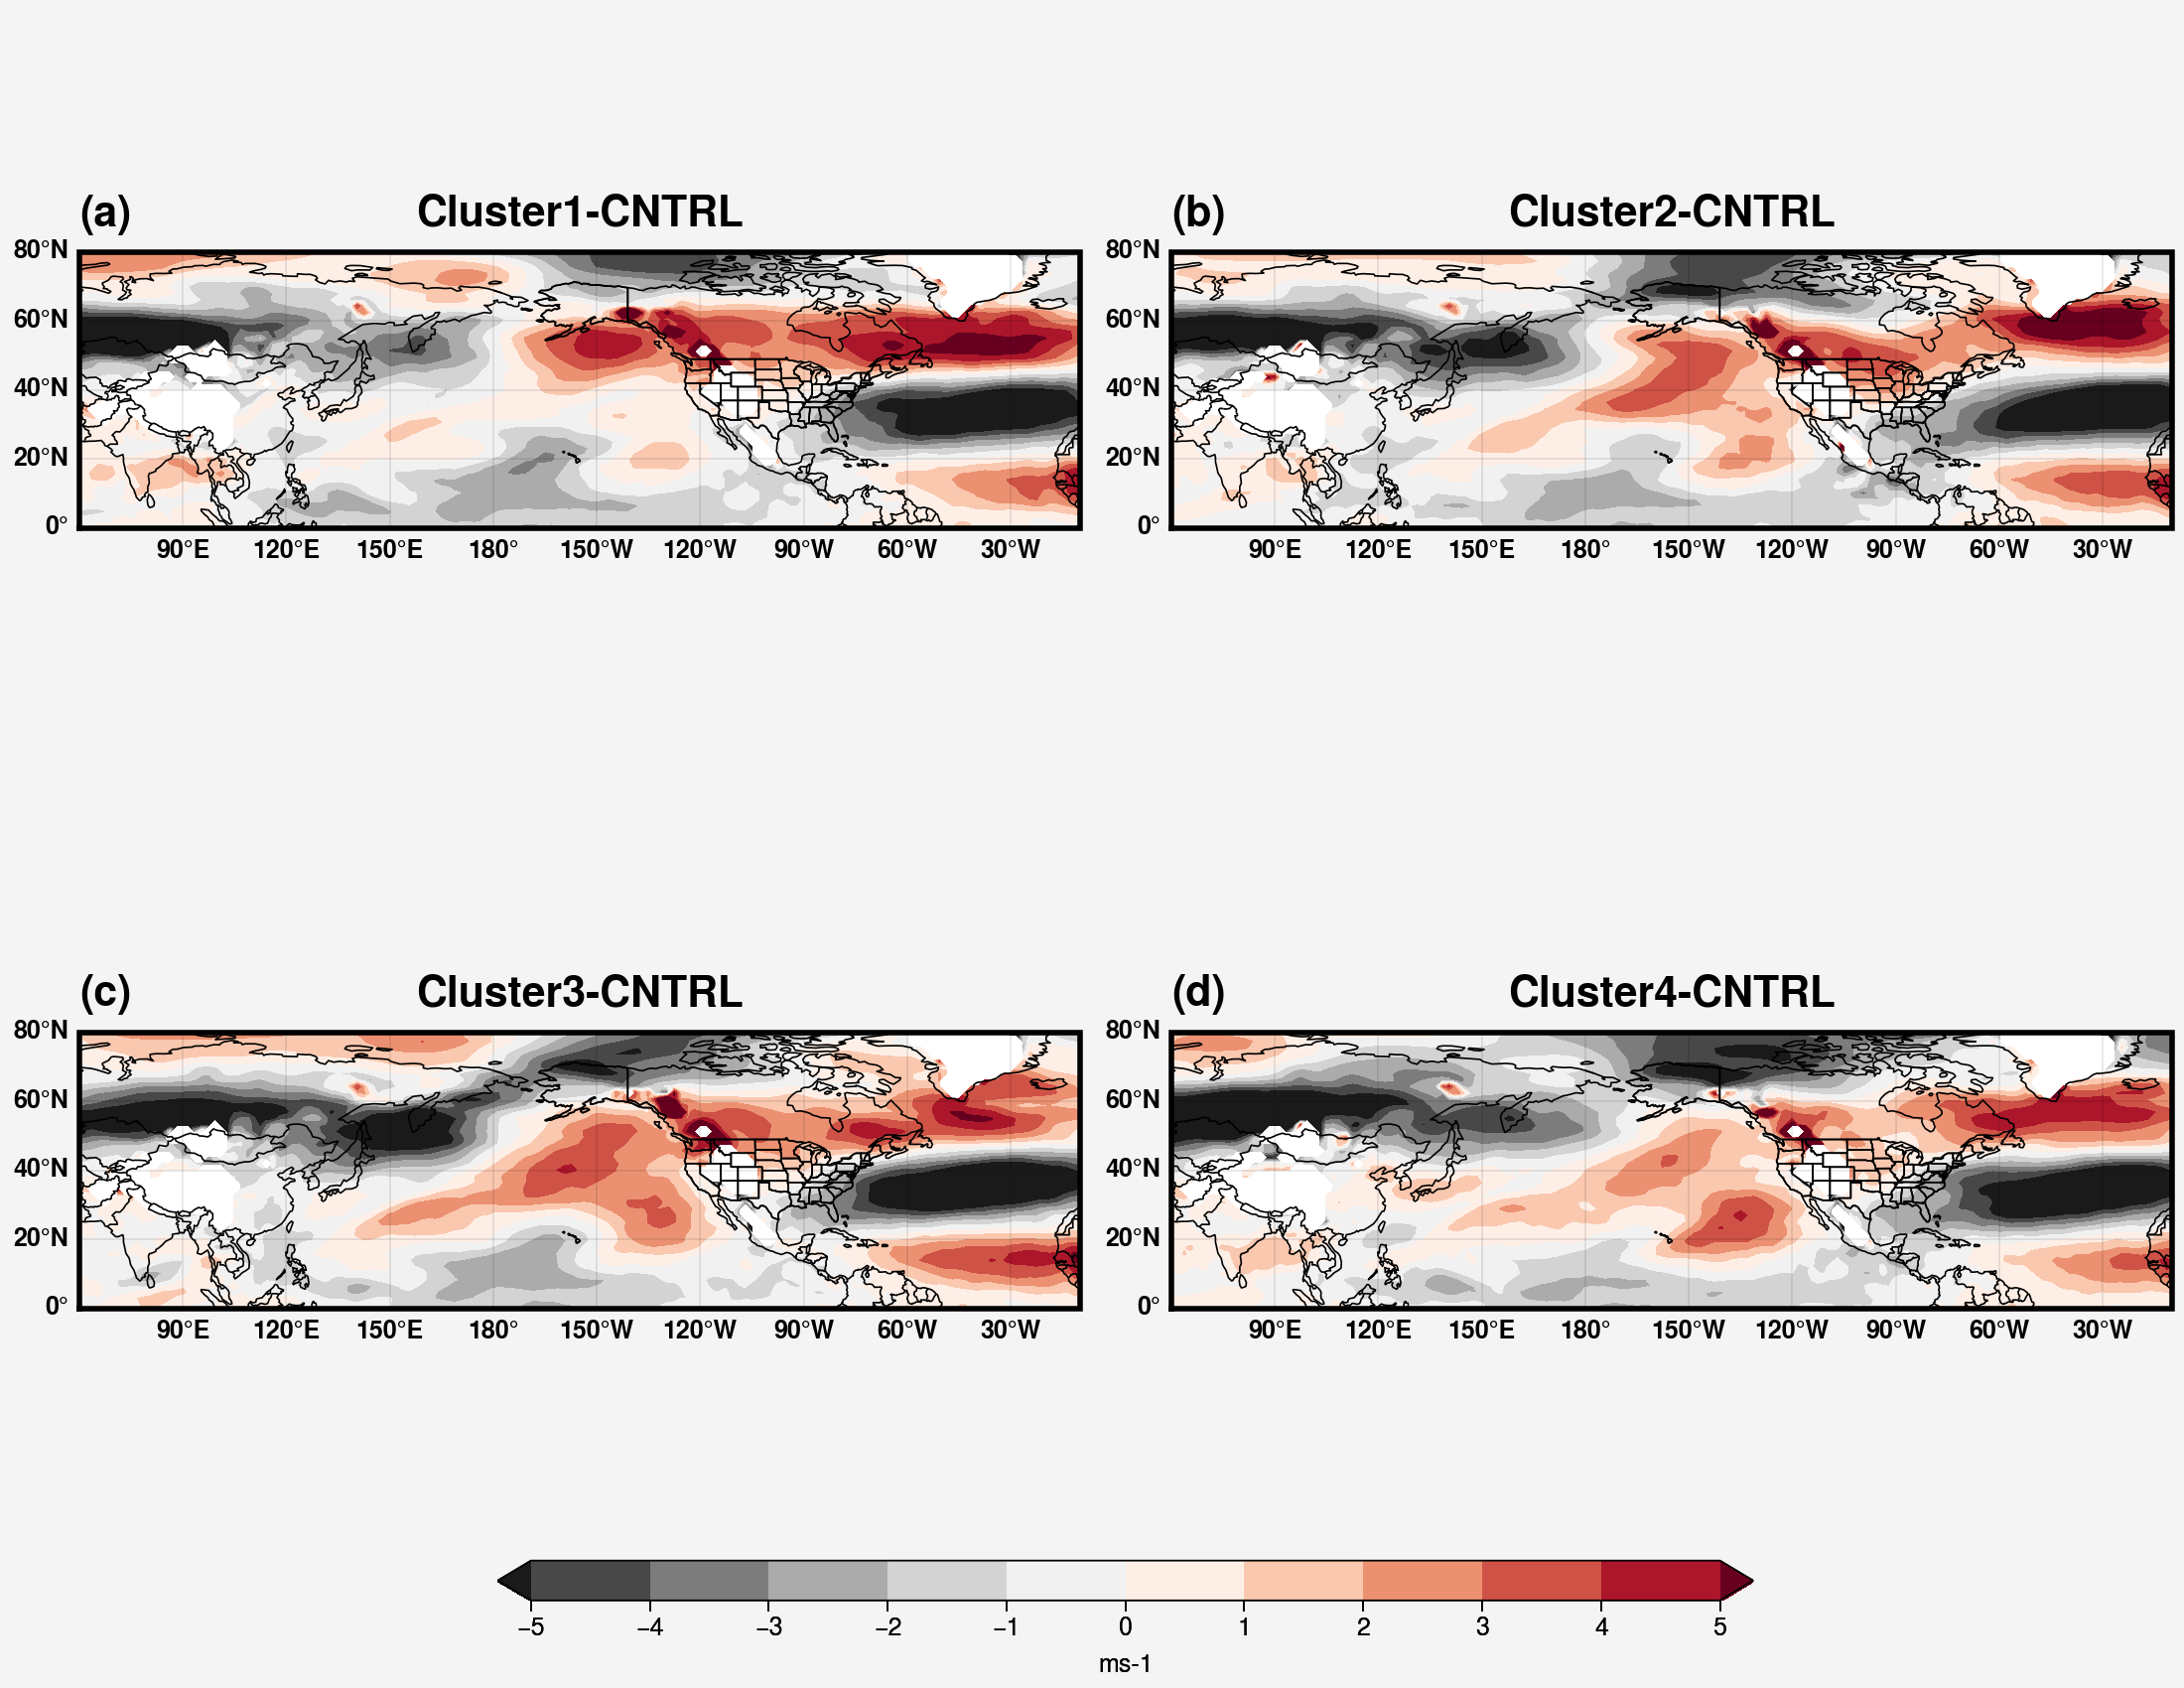

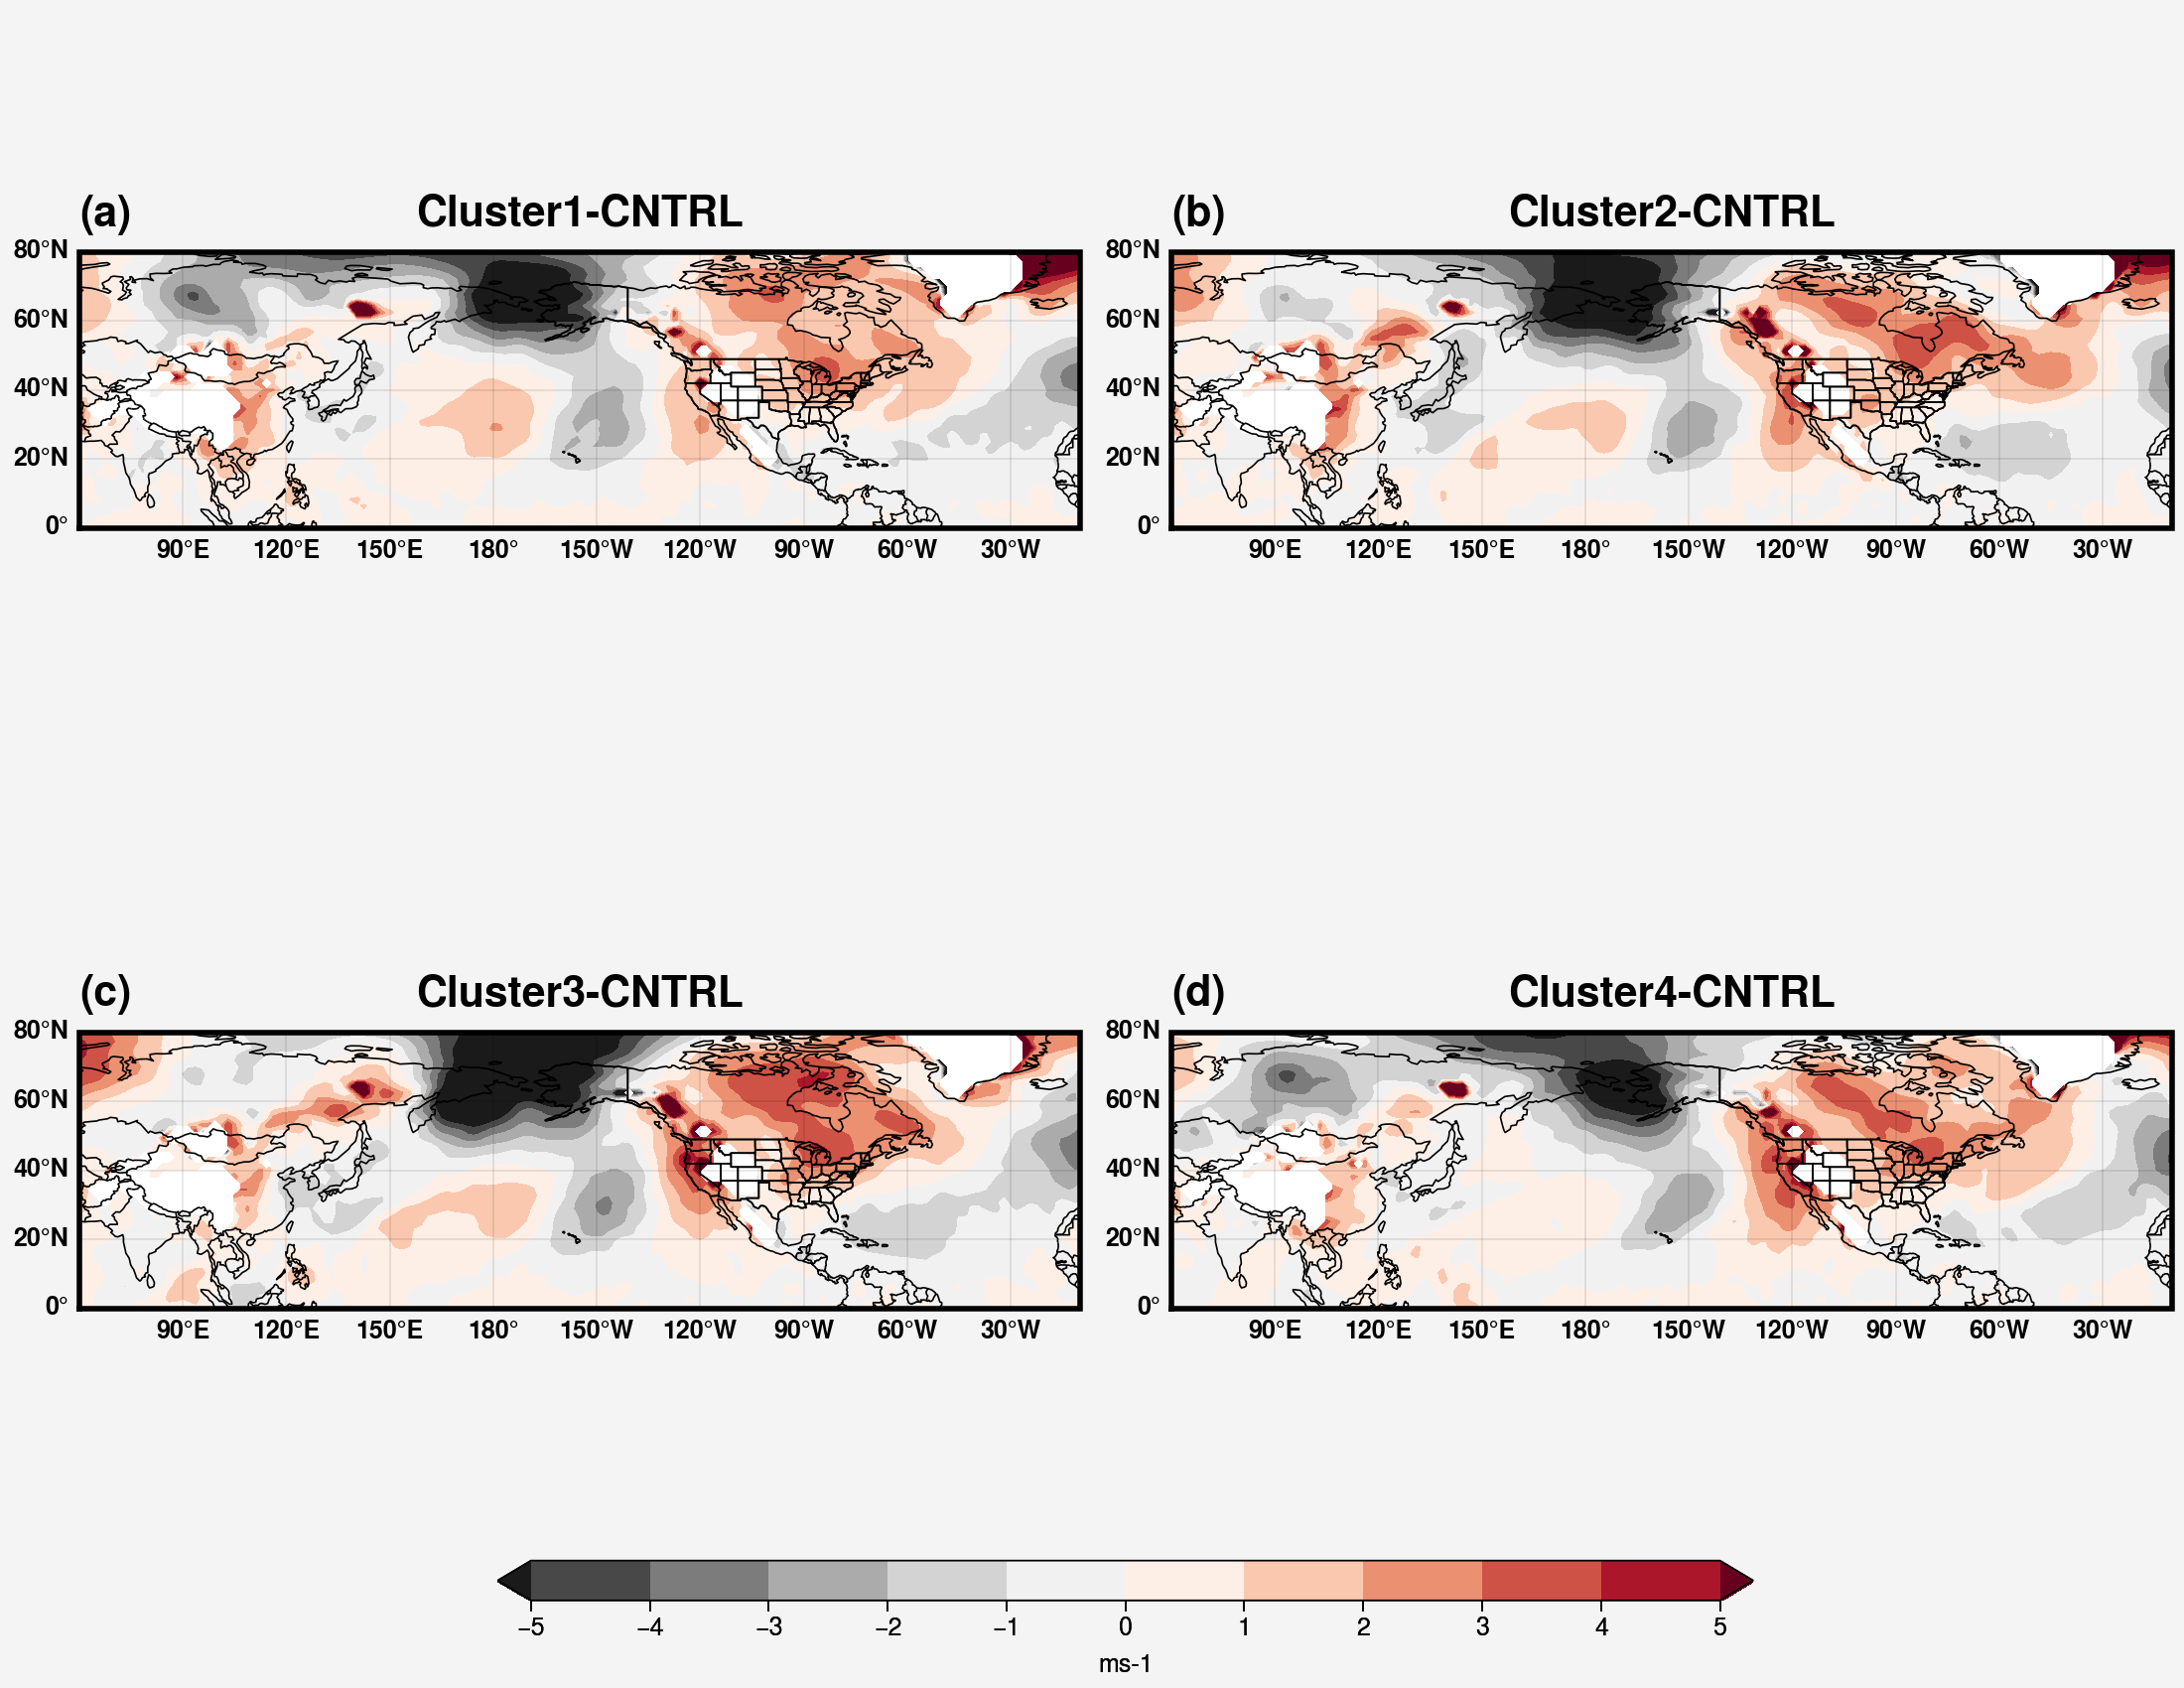

In [13]:
clusters = [diff_cluster1, diff_cluster2, diff_cluster3, diff_cluster4]
titles = ['Cluster1-CNTRL', 'Cluster2-CNTRL', 'Cluster3-CNTRL', 'Cluster4-CNTRL']
#plev=200
#clevs=np.arange(-10,11,1)
plev=850
clevs=np.arange(-5,6,1)
latreg=[0,80]
lonreg=[60,350]
plot_exps(clusters,titles,plev,clevs,latreg=latreg,lonreg=lonreg)

<xarray.DataArray 'convergence' (lat: 95, lon: 191)>
dask.array<mul, shape=(95, 191), dtype=float64, chunksize=(95, 191), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 86.72 84.86 83.0 81.13 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
    lev      float64 850.0
<xarray.DataArray 'convergence' (lat: 95, lon: 191)>
dask.array<mul, shape=(95, 191), dtype=float64, chunksize=(95, 191), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 86.72 84.86 83.0 81.13 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
    lev      float64 850.0
<xarray.DataArray 'convergence' (lat: 95, lon: 191)>
dask.array<mul, shape=(95, 191), dtype=float64, chunksize=(95, 191), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 86.72 84.86 83.0 81.13 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 3

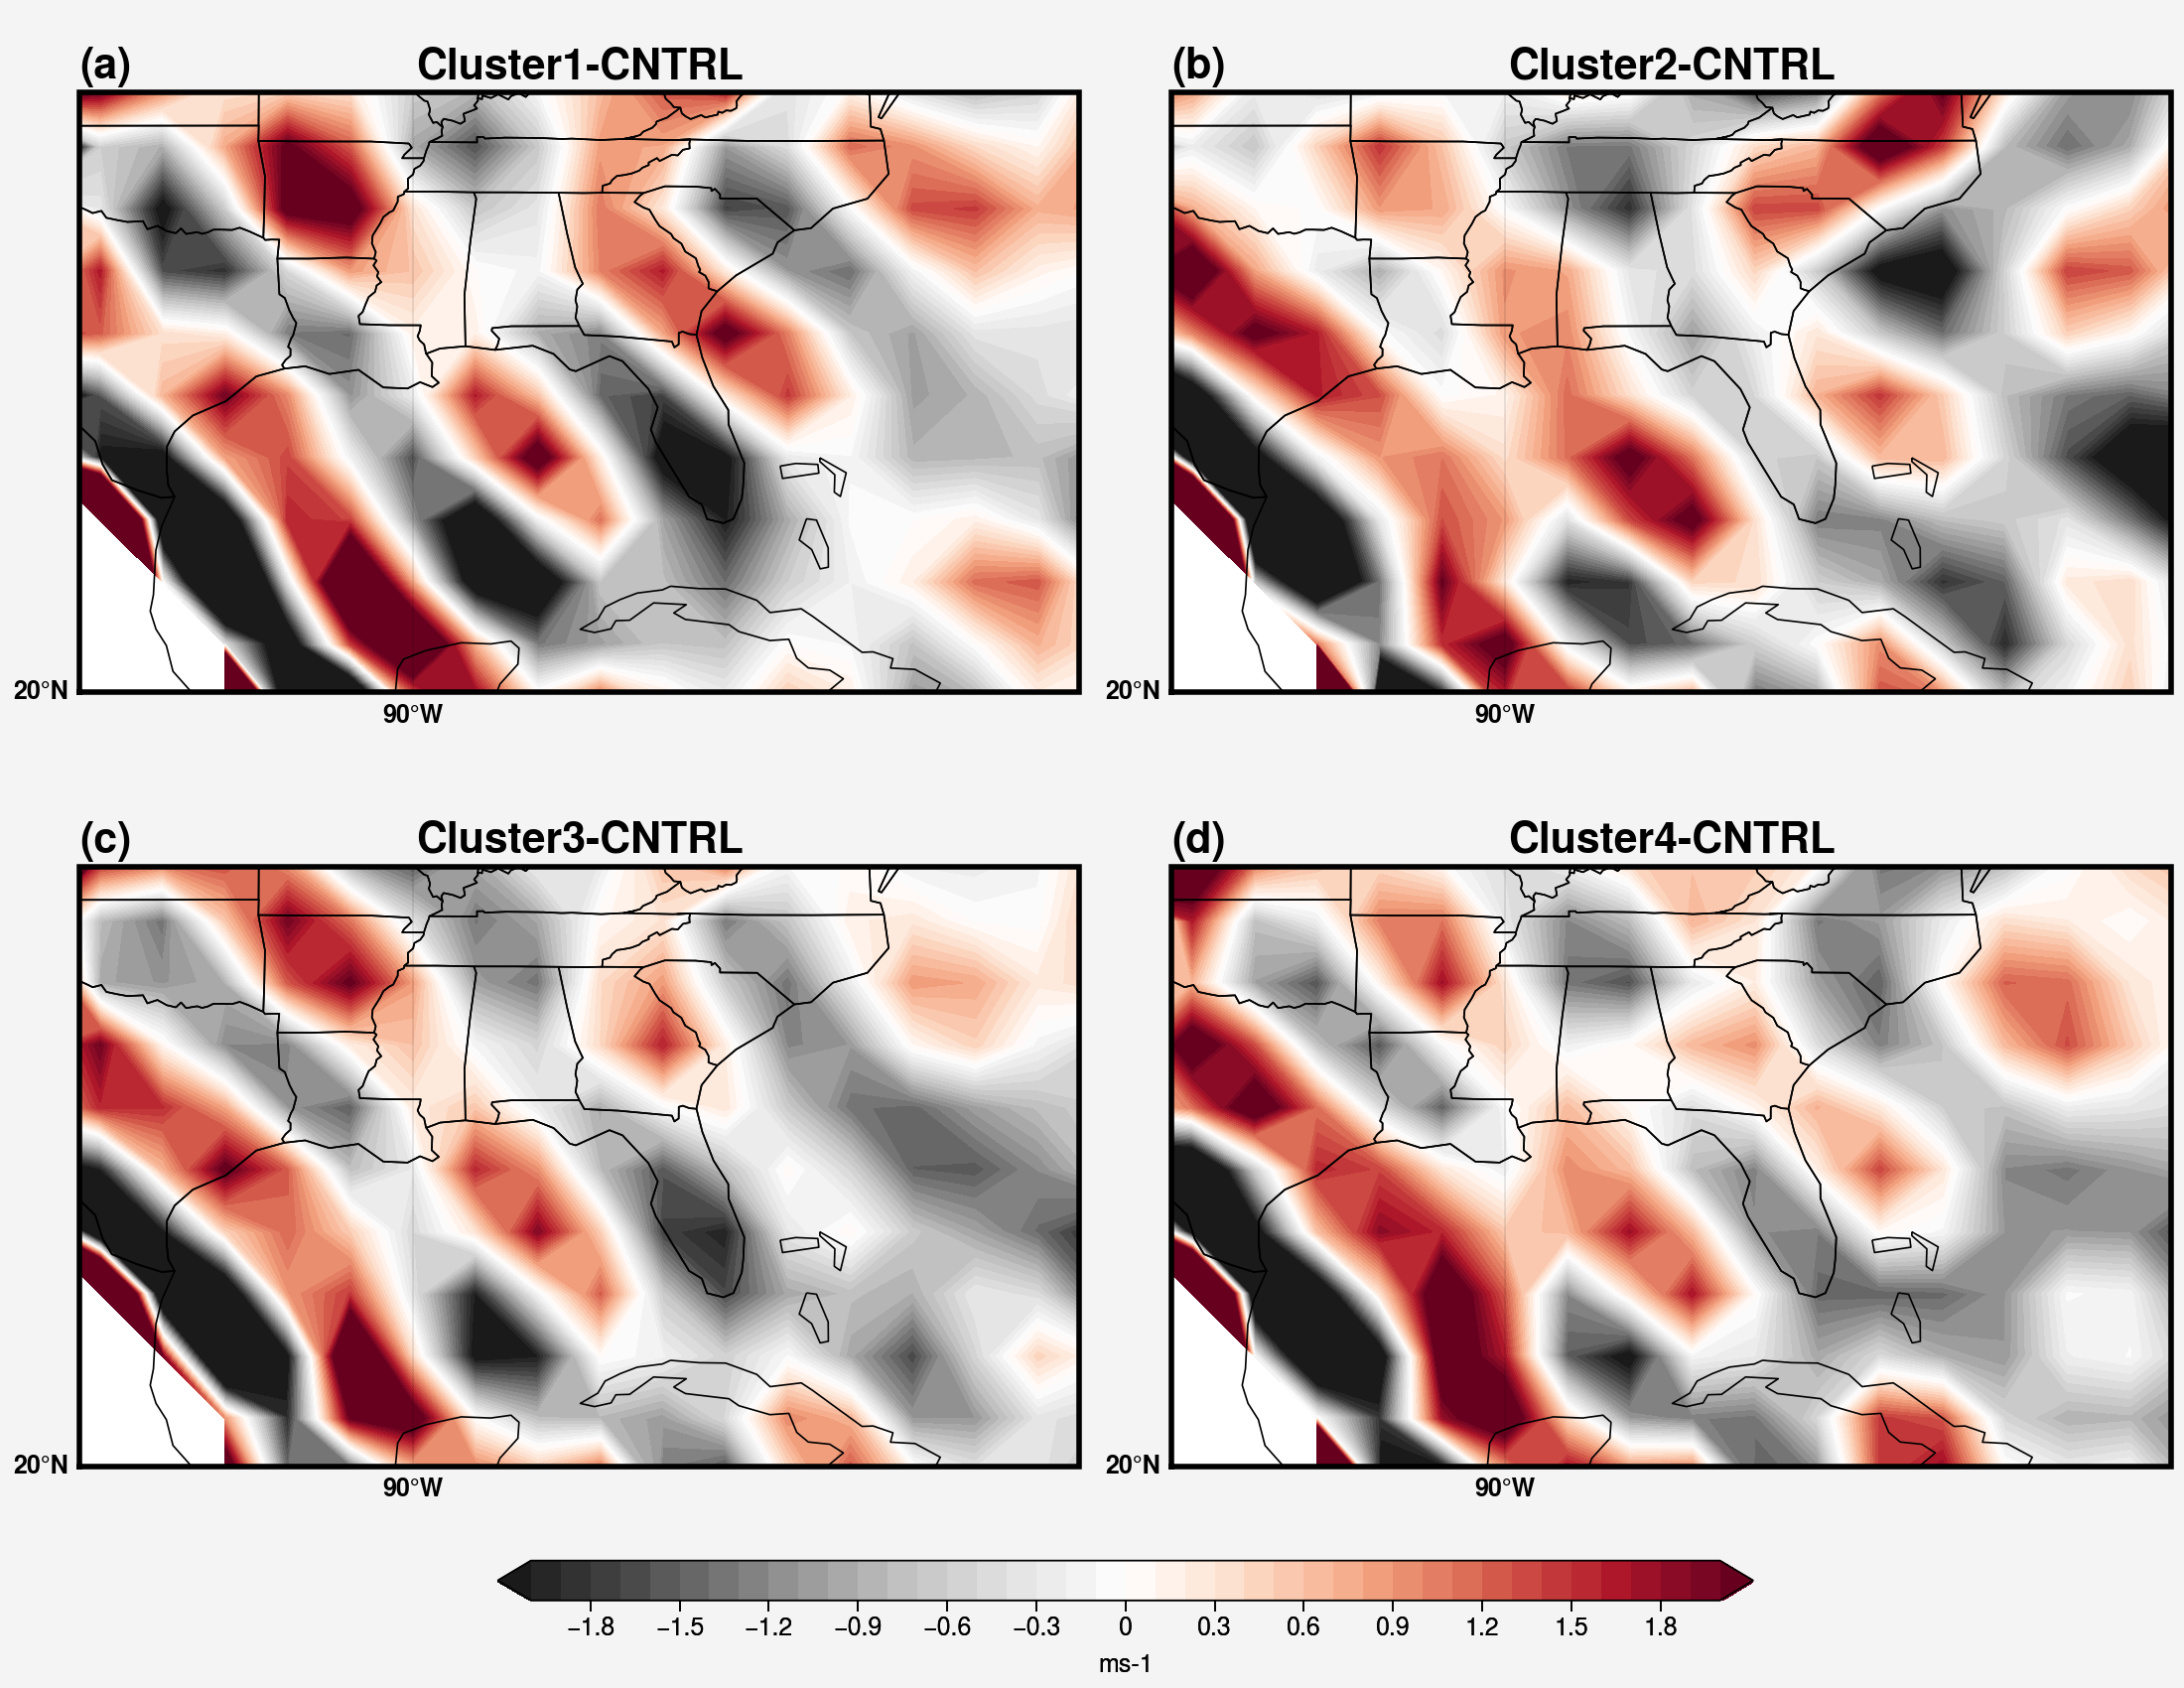

In [14]:
convergence_list = []

for ds in clusters:
    u = ds['u'].sel(lev=850)
    v = ds['v'].sel(lev=850)

    # Earth radius and lat in radians
    Re = 6.371e6
    lat_rad = np.deg2rad(u.lat)

    # dx, dy in meters
    dx = (2 * np.pi * Re * np.cos(lat_rad) / 360) * u.lon.diff('lon').mean()
    dy = (2 * np.pi * Re / 360) * u.lat.diff('lat').mean()

    du_dx = u.diff('lon') / dx
    dv_dy = v.diff('lat') / dy

    # Pad to match original shape
    du_dx = du_dx.pad(lon=(0, 1), mode='constant', constant_values=np.nan)
    dv_dy = dv_dy.pad(lat=(0, 1), mode='constant', constant_values=np.nan)

    convergence = -(du_dx + dv_dy)
    convergence.name = 'convergence'

    convergence_list.append(convergence * 1e6)  # Convert to 10^-5 s^-1
clevs=np.arange(-2,2.1,0.1) 
latreg=[20,38]
lonreg=[260,290]
plot_convergence(convergence_list, titles, plev, clevs, latreg=latreg, lonreg=lonreg)